In [6]:
!pip install imbalanced-learn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                               roc_curve, confusion_matrix, precision_recall_curve)

In [8]:
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.3f}%")
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


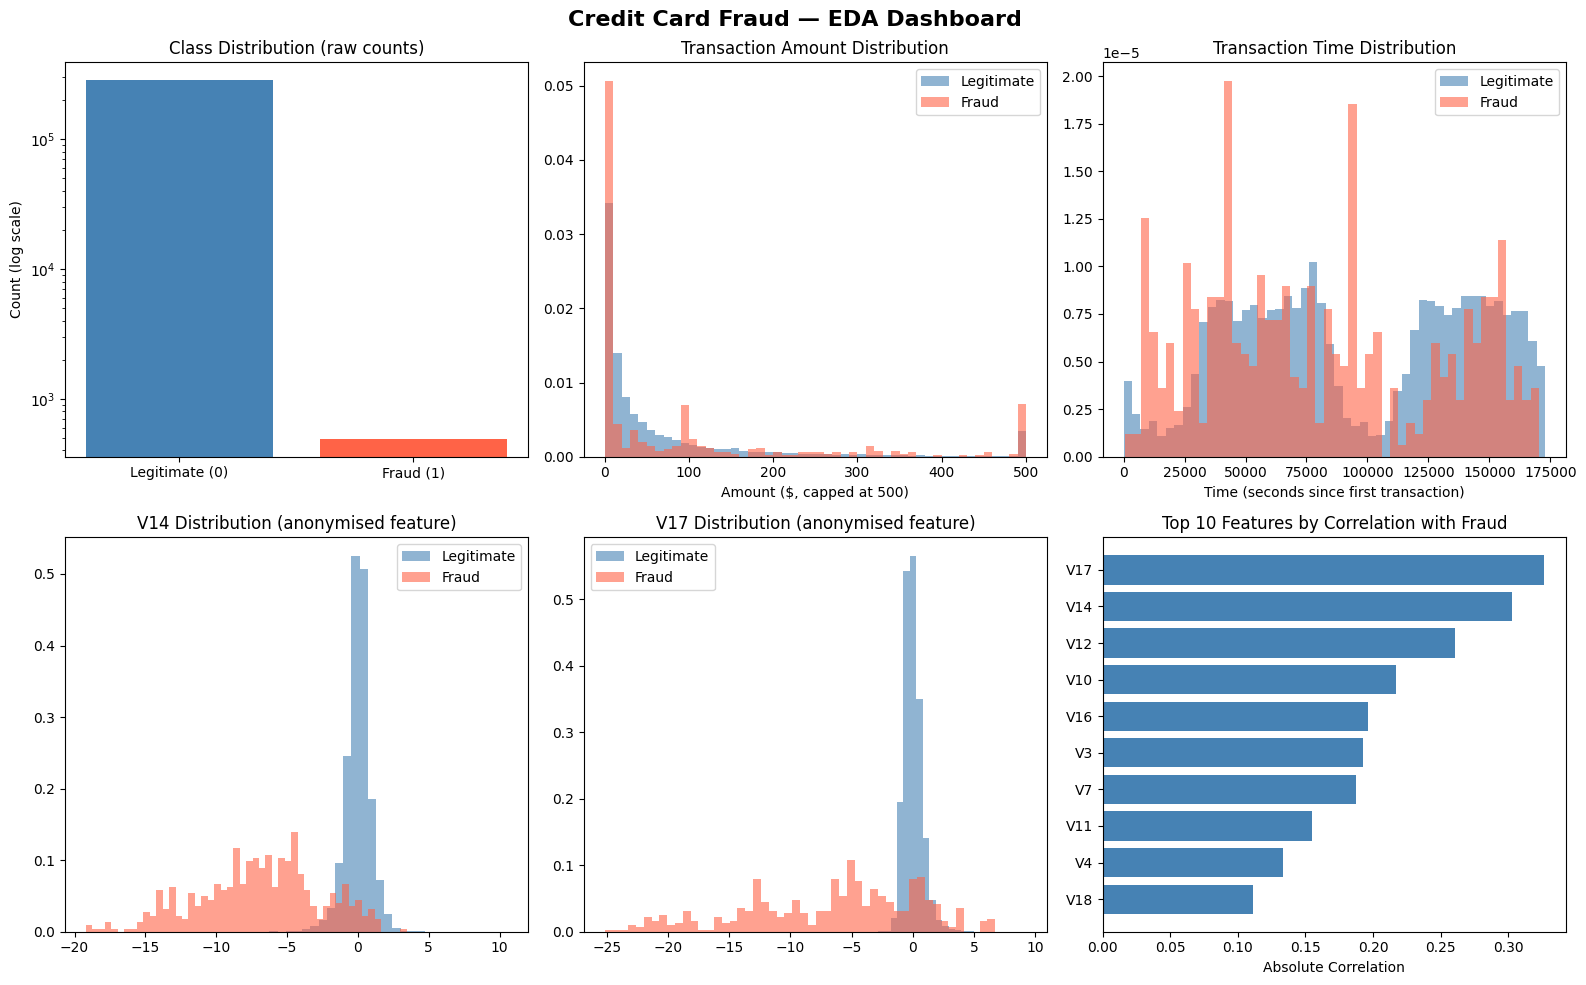


Top 10 correlations with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Credit Card Fraud — EDA Dashboard', fontsize=16, fontweight='bold')

# 1. Class distribution
class_counts = df['Class'].value_counts()
axes[0,0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts, color=['steelblue','tomato'])
axes[0,0].set_title('Class Distribution (raw counts)')
axes[0,0].set_yscale('log')
axes[0,0].set_ylabel('Count (log scale)')

# 2. Transaction Amount by class
axes[0,1].hist(df[df['Class']==0]['Amount'].clip(0,500), bins=50, alpha=0.6,
               label='Legitimate', color='steelblue', density=True)
axes[0,1].hist(df[df['Class']==1]['Amount'].clip(0,500), bins=50, alpha=0.6,
               label='Fraud', color='tomato', density=True)
axes[0,1].set_title('Transaction Amount Distribution')
axes[0,1].set_xlabel('Amount ($, capped at 500)')
axes[0,1].legend()

# 3. Time distribution
axes[0,2].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6,
               label='Legitimate', color='steelblue', density=True)
axes[0,2].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.6,
               label='Fraud', color='tomato', density=True)
axes[0,2].set_title('Transaction Time Distribution')
axes[0,2].set_xlabel('Time (seconds since first transaction)')
axes[0,2].legend()

# 4. V14 by class (one of the most predictive features)
axes[1,0].hist(df[df['Class']==0]['V14'], bins=50, alpha=0.6,
               label='Legitimate', color='steelblue', density=True)
axes[1,0].hist(df[df['Class']==1]['V14'], bins=50, alpha=0.6,
               label='Fraud', color='tomato', density=True)
axes[1,0].set_title('V14 Distribution (anonymised feature)')
axes[1,0].legend()

# 5. V17 by class (another strong feature)
axes[1,1].hist(df[df['Class']==0]['V17'], bins=50, alpha=0.6,
               label='Legitimate', color='steelblue', density=True)
axes[1,1].hist(df[df['Class']==1]['V17'], bins=50, alpha=0.6,
               label='Fraud', color='tomato', density=True)
axes[1,1].set_title('V17 Distribution (anonymised feature)')
axes[1,1].legend()

# 6. Correlation with target (top 10)
corr = df.corr()['Class'].abs().sort_values(ascending=False)[1:11]
axes[1,2].barh(corr.index[::-1], corr.values[::-1], color='steelblue')
axes[1,2].set_title('Top 10 Features by Correlation with Fraud')
axes[1,2].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.savefig('fraud_eda_dashboard.png', dpi=150)
plt.show()

print("\nTop 10 correlations with Class:")
print(corr)

In [10]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Fraud in train: {y_train.sum()} | Fraud in test: {y_test.sum()}")

Train: 227845 | Test: 56962
Fraud in train: 394 | Fraud in test: 98


In [11]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time','Amount']] = scaler.fit_transform(X_train[['Time','Amount']])
X_test_scaled[['Time','Amount']]  = scaler.transform(X_test[['Time','Amount']])

In [12]:
# Logistic Regression with balanced class weights
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, lr_pred))
print(f"AUC: {lr_auc:.4f}\n")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:,1])

print("=== RANDOM FOREST ===")
print(classification_report(y_test, rf_pred))
print(f"AUC: {rf_auc:.4f}")

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC: 0.9722

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.9529


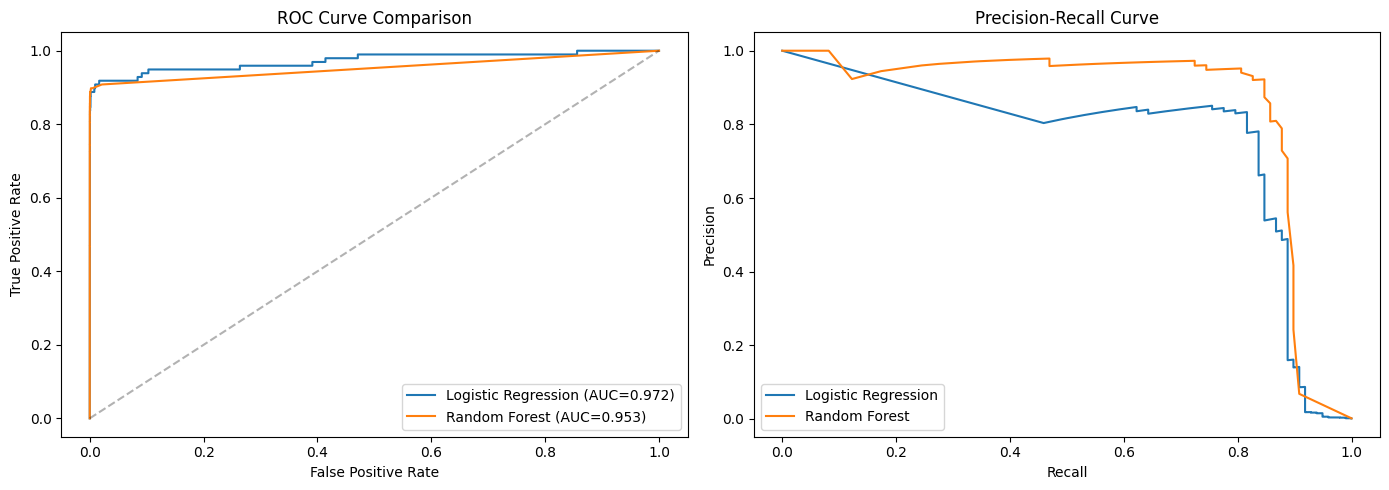

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test_scaled)[:,1])

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall curve (more informative than ROC for imbalanced data)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr.predict_proba(X_test_scaled)[:,1])
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf.predict_proba(X_test_scaled)[:,1])

axes[1].plot(rec_lr, prec_lr, label='Logistic Regression')
axes[1].plot(rec_rf, prec_rf, label='Random Forest')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('fraud_model_comparison.png', dpi=150)
plt.show()

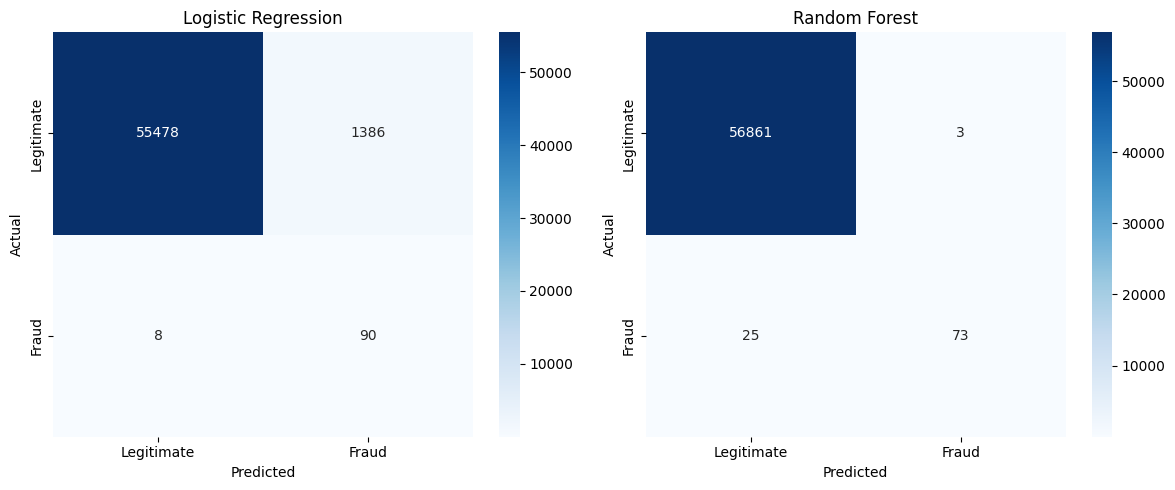

In [14]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('fraud_confusion_matrices.png', dpi=150)
plt.show()

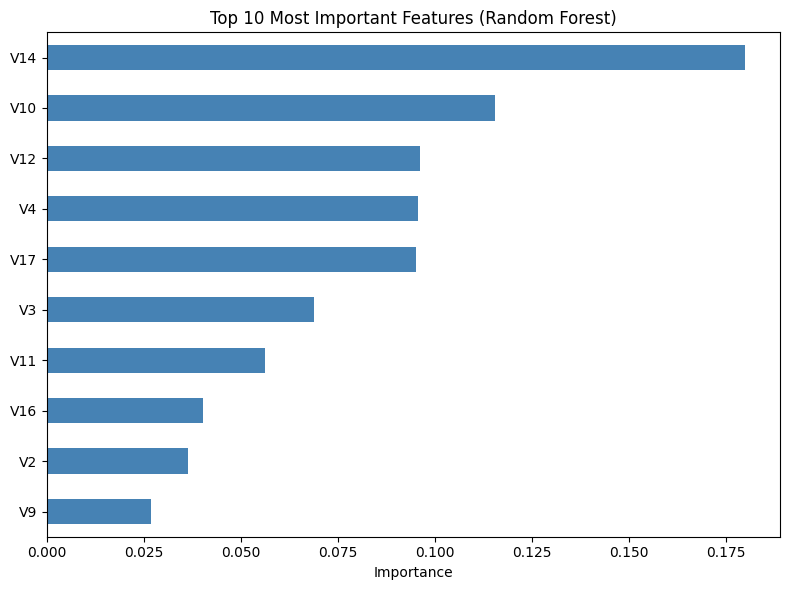

V14    0.179857
V10    0.115442
V12    0.096206
V4     0.095646
V17    0.095113
V3     0.068669
V11    0.056112
V16    0.040303
V2     0.036265
V9     0.026888
dtype: float64


In [15]:
# Feature importance from Random Forest
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
importance.plot(kind='barh', color='steelblue')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fraud_feature_importance.png', dpi=150)
plt.show()
print(importance)

In [16]:
# Final model comparison table for your writeup
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUC': [lr_auc, rf_auc],
    'Recall (Fraud)': [90/98, 73/98],
    'Precision (Fraud)': [90/(90+1386), 73/(73+3)],
    'False_Positives': [1386, 3],
    'Frauds_Missed': [8, 25]
})
print(comparison)
comparison.to_csv('fraud_model_comparison.csv', index=False)

                 Model       AUC  Recall (Fraud)  Precision (Fraud)  \
0  Logistic Regression  0.972169        0.918367           0.060976   
1        Random Forest  0.952908        0.744898           0.960526   

   False_Positives  Frauds_Missed  
0             1386              8  
1                3             25  
